In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from sympy.stats.sampling.sample_scipy import scipy
from scipy.optimize import differential_evolution as de
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

In [2]:
from add_roughness import *

z_grid_init = np.load("z_grid_init.npy")
profile_sld_re_init = np.load("profile_sld_re_init.npy")

def plot_density_profile_1(matr):
    matrix = matr.clone()
    depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
    U = (1.e-0) * matrix[:, 1].real

    x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
    y_fill = torch.repeat_interleave(U, 2)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x_fill.detach().cpu().numpy(),
        y=y_fill.detach().cpu().numpy(),
        mode="lines",
        line=dict(color="darkgreen"),
        fill="tozeroy"
    ))
    fig.add_trace(go.Scatter(
        x=z_grid_init+15,
        y=profile_sld_re_init,
        mode="lines",
        line=dict(color="blue")
    ))

    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

plot_density_profile_1(transform_array(matr, rough_res))

C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning:

Casting complex values to real discards the imaginary part



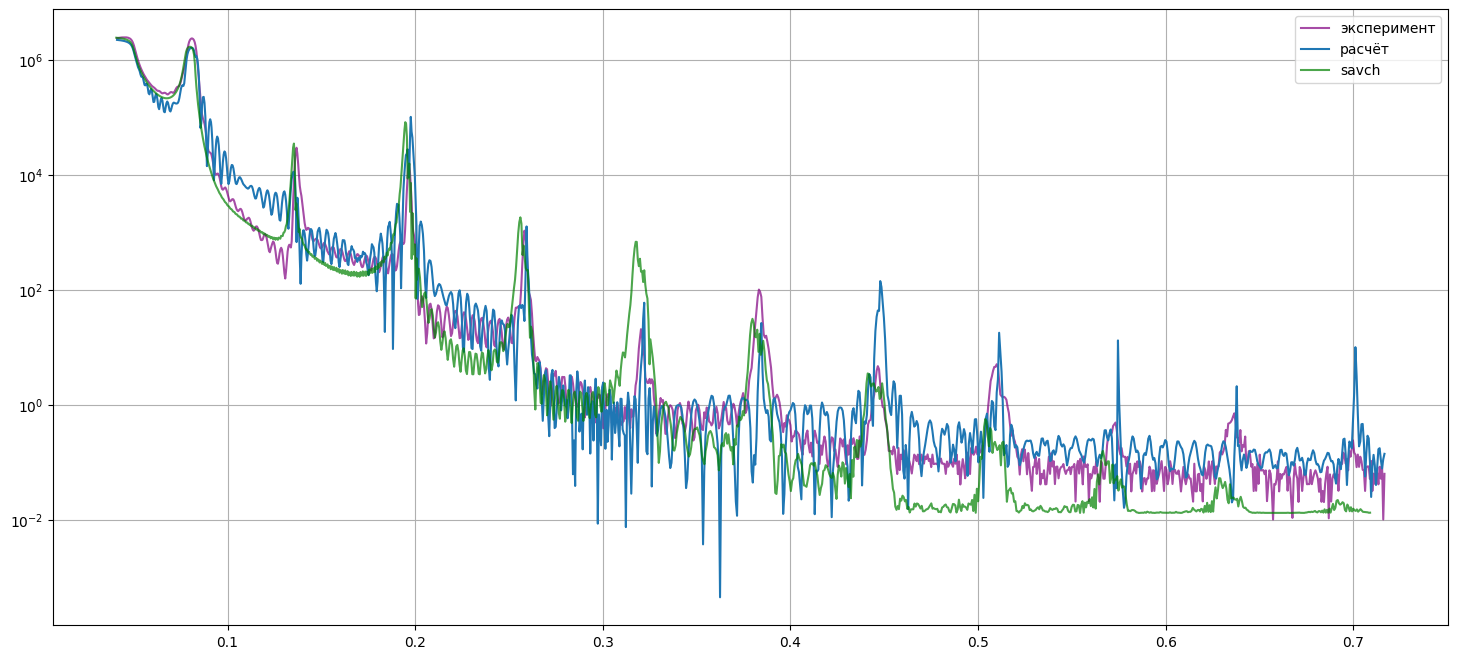

In [3]:
R_sav = np.load("R_in_savch.npy")
q_sav = np.load("q_in_savch.npy")

q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524-0.00207903*1.0e+10
r_mod, r_mod_conv= reflectometry(q, matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(q*1e-10, r0, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod.tolist())]*1e-10, (I0*r_mod).tolist(), label= 'расчёт')
ax.plot(q_sav, R_sav/76.25, color='green', alpha=0.7, label= 'savch')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [4]:
from optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [5]:
from variables import *
x_d = initial_d.reshape(-1, 8)[:, 0:2].flatten()

In [6]:
objective_function1 = loss_function.compare
loss1 = objective_function1(matr, sigma1, sigma2, I0, Ibkg, ref_type='model')

loss1

tensor(1.5615, dtype=torch.float64, grad_fn=<SumBackward0>)

Optimizing:  99%|████████████████████████████████████████████████████████▍| 99/100 [04:14<00:02,  2.48s/it, lr=3.09e-01]

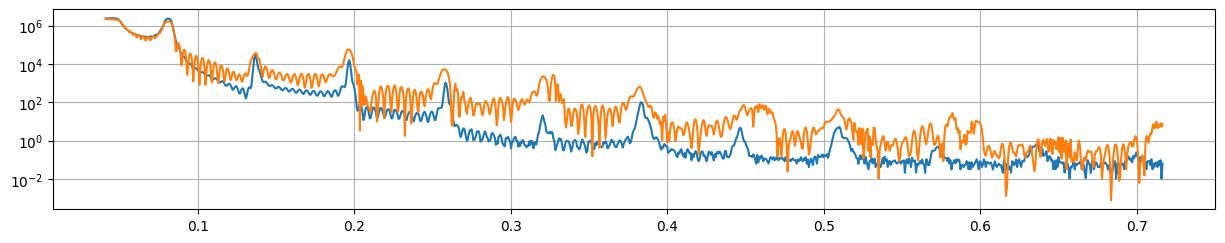

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [04:17<00:00,  2.58s/it, lr=3.09e-01]


Stage 1: Learning Rate=0.16, Iterations=100, relative_loss=0.540579052939293


Optimizing: 100%|███████████████████████████████████████████████████████▋| 199/200 [08:24<00:02,  2.57s/it, lr=9.22e-02]

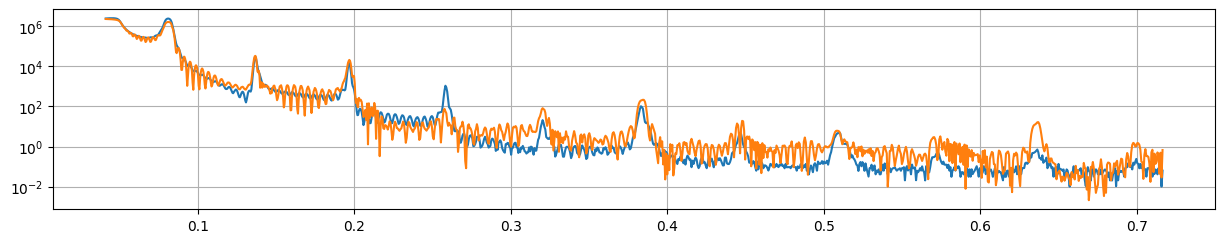

Optimizing: 100%|████████████████████████████████████████████████████████| 200/200 [08:27<00:00,  2.54s/it, lr=9.22e-02]


Stage 2: Learning Rate=0.05, Iterations=200, relative_loss=0.01037699201037368


Optimizing: 100%|███████████████████████████████████████████████████████▊| 399/400 [16:46<00:02,  2.57s/it, lr=3.37e-02]

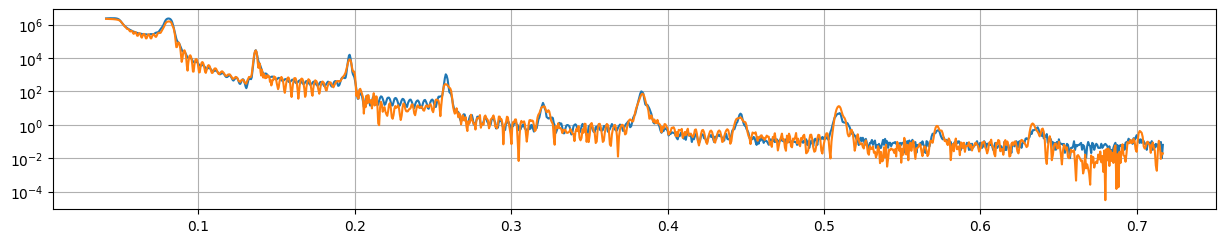

Optimizing: 100%|████████████████████████████████████████████████████████| 400/400 [16:49<00:00,  2.52s/it, lr=3.37e-02]


Stage 3: Learning Rate=0.02, Iterations=400, relative_loss=0.24427592656571234


Optimizing:  99%|████████████████████████████████████████████████████████▍| 99/100 [04:16<00:02,  2.59s/it, lr=2.89e-02]

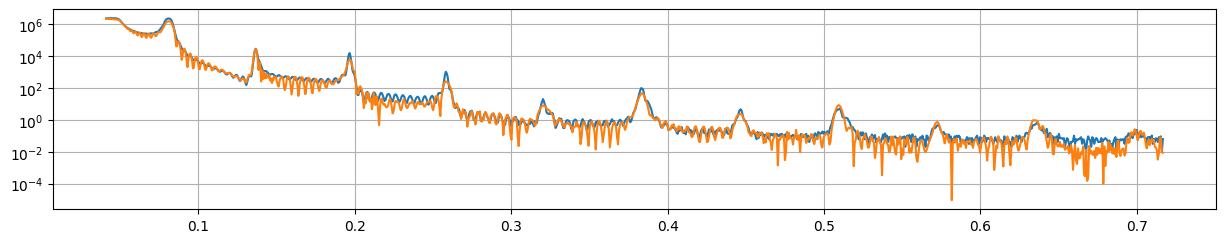

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [04:19<00:00,  2.60s/it, lr=2.89e-02]


Stage 4: Learning Rate=0.015, Iterations=100, relative_loss=0.7750455543391334


Optimizing:  99%|███████████████████████████████████████████████████████▋| 149/150 [06:23<00:02,  2.48s/it, lr=1.13e-02]

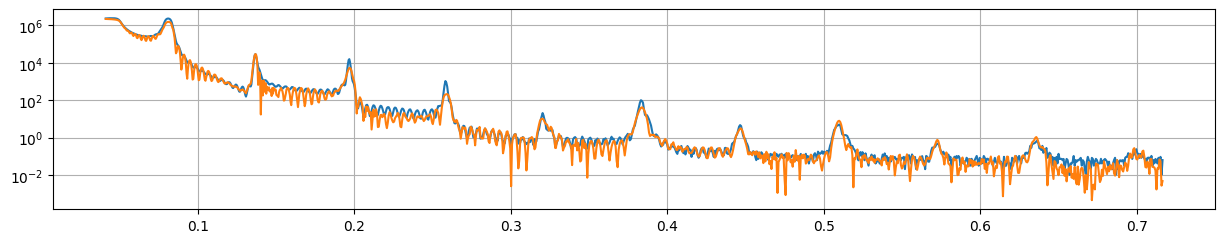

Optimizing: 100%|████████████████████████████████████████████████████████| 150/150 [06:26<00:00,  2.58s/it, lr=1.13e-02]


Stage 5: Learning Rate=0.006, Iterations=150, relative_loss=0.8924547096515028


In [7]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model')
]

learning_rates = [0.16, 0.05, 0.02, 0.015, 0.006]
iterations = [100, 200, 400, 100, 150]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses = pie_optimizer(q, r, (0.9655, 0.99),    0.991,
 0.004,
    learning_rates,
    iterations,
    loss_classes
)

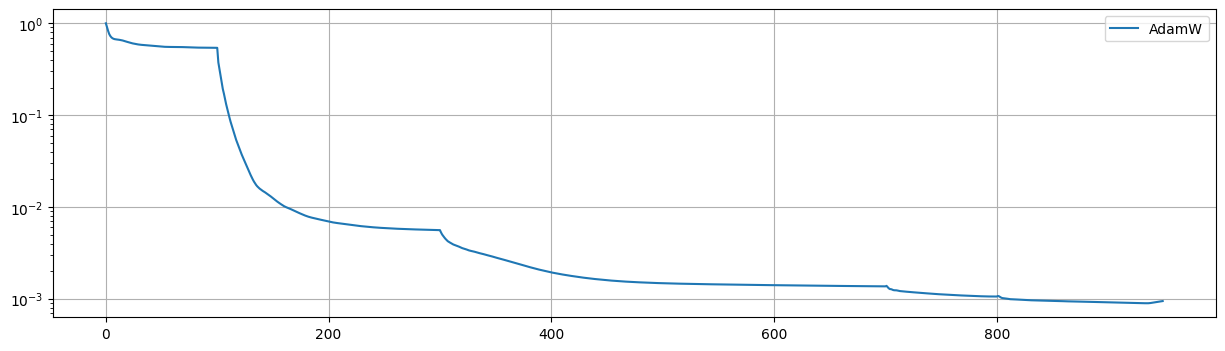

In [10]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

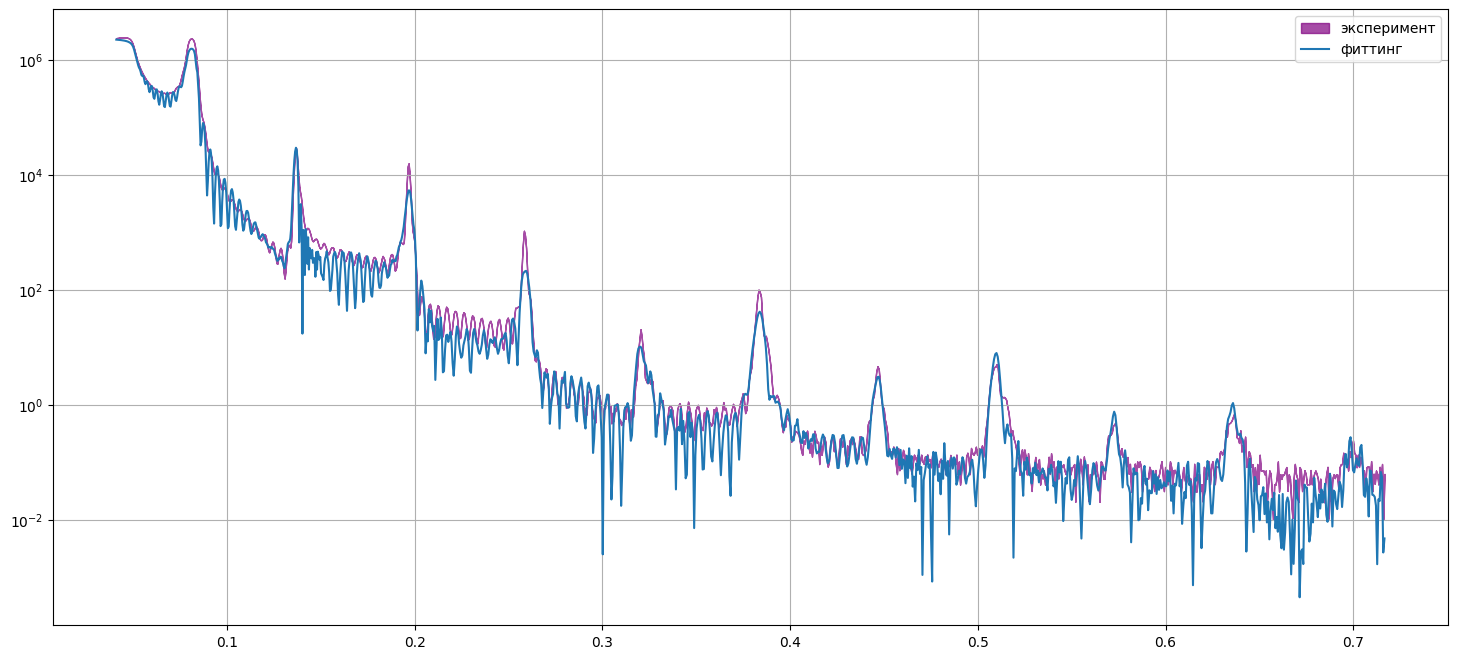

In [17]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 8), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,
                       torch.tensor([0, 8, 1, 2, 3, 4, 5, 6, 7])]
r_mod, r_mod_conv= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 9), combined_x_for_print.reshape(-1, 9)), axis= 0), 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r0, r0, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist(), label= 'фиттинг')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [12]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 8), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 8, 1, 2,3,4,5,6,7])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 9), combined_x_for_print.reshape(-1, 9)), axis= 0), rough_res))
fig.show()

In [13]:
matrix = transform_array(torch.cat((matr[0,:].reshape(-1, 9), combined_x_for_print.reshape(-1, 9)), axis= 0), rough_res)
matrix = torch.cat((matrix,torch.zeros(matrix.shape[0]).reshape(-1, 1)), axis=1)

In [14]:
combined_x_for_print[:,0:3]

tensor([[63.1312+0.0000j, 64.4050-1.3485j, 39.3370+0.0000j],
        [45.3680+0.0000j, 35.7980-3.0109j, 30.5869+0.0000j],
        [54.8573+0.0000j, 64.4000-1.3484j, 32.5515+0.0000j],
        [44.4111+0.0000j, 35.8000-3.0111j, 31.1957+0.0000j],
        [54.7331+0.0000j, 64.4000-1.3484j, 34.1338+0.0000j],
        [43.7391+0.0000j, 35.8000-3.0111j, 36.1630+0.0000j],
        [97.0474+0.0000j, 45.2219-1.9686j, 28.7543+0.0000j],
        [58.3600+0.0000j, 64.4000-1.3484j, 31.1122+0.0000j],
        [43.2234+0.0000j, 35.7980-3.0109j, 38.9555+0.0000j],
        [51.5573+0.0000j, 64.4000-1.3484j, 47.2550+0.0000j],
        [48.0830+0.0000j, 35.7980-3.0109j, 44.3573+0.0000j],
        [45.0250+0.0000j, 64.4000-1.3484j, 46.7917+0.0000j],
        [44.2654+0.0000j, 35.7980-3.0109j, 42.5264+0.0000j],
        [99.9900+0.0000j, 20.0720-0.8702j, 22.5822+0.0000j]])